# 目录
1. [对商品评论数据的分析](#section1)
 * 1.1 [对评论的情感分析](#section1_1)
 * 1.2 [规范数据](#section1_2)
2. [对商品数据的分析](#section2)
 * 2.1 [合并表](#section2_1)

3. [对用户行为数据的分析](#section3)
 * 3.1 [规范化数据](#section3_1)
 * 3.2 [统计用户行为](#section3_2)
 * 3.3 [优质客户](#section3_3)
 * 3.4 [合并表](#section3_4)
4. [推荐系统](#section4)
 * 4.1 [基于ALS（交替最小二乘法）的协同过滤推荐](#section4_1)
 * 4.2 [ALS模型评估](#section4_2)

# 1.  关于对商品评论数据的情感分析  <a class="anchor" id="section1"></a>

In [58]:
import pandas as pd  # 数据分析库
from textblob import TextBlob  # 英文情感分析库
import matplotlib.pyplot as plt  # 画图
from wordcloud import WordCloud  # 绘制词云图
from wordcloud import ImageColorGenerator
from PIL import Image
import numpy as np

## 1.1 情感分析  <a class="anchor" id="section1_1"></a>

### 1.1.1 读取数据

In [2]:
import pandas as pd


chunk_size = 500000 # 每一块的行数
chunks = []

for chunk in pd.read_csv('D:\\Datas\\datas\\review.csv', chunksize=chunk_size):
    # 处理每个chunk的数据
    chunks.append(chunk)
data = pd.concat(chunks, axis=0)
data.head(10)

,item_id,rater_uid,feedback,,gmt_create
0,3,u10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,NaN,2013-06-27 16:50:13
1,4,u7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,NaN,2013-08-22 17:15:45
2,4,u6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,NaN,2013-08-18 11:07:29
3,5,u7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,NaN,2013-08-29 15:26:50
4,5,u530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,NaN,2013-07-24 19:24:22
5,5,u9902915,商品 没 的 说 ， 很 好 ， 包装 很 结实 ， 打开 箱子 笑 的 我 来 ， 包裹 ...,NaN,2013-09-05 16:34:28
6,5,u9621739,就是 这 个 味 ， 满意 ！ 还 可以 哦,NaN,2013-09-29 20:04:25
7,6,u11614546,买 了 一 件 不 能 用 ， 妈妈 让 退 ， 商家 不 给 退 ， 扔 了 。 一点 效...,NaN,2013-09-15 13:09:27
8,6,u13715238,不好意思 ， 评价 晚 了 ， 太 忙 了 ， 东西 确实 很 不错 ， 值得 推荐 给 大...,NaN,2013-05-23 10:55:42
9,6,u462198,婆婆 用 上 了 ， 很 满意 ！,NaN,2013-06-03 14:09:32


### 1.1.2 数据的情感分析

In [71]:
#打分情感分析
#情感分析的结果是一个小数，越接近1，说明越偏向积极；越接近0，说明越偏向消极。
from snownlp import SnowNLP

score_list = []  # 情感评分值
tag_list = []  # 打标分类结果
for com in data['feedback']:
    tag = ''
    judge = SnowNLP(str(com))
    sentiment_score = judge.sentiments
    score_list.append(sentiment_score)
    if sentiment_score >= 0.75:
        tag = "好评"
    elif sentiment_score >= 0.5:
        tag = "一般"
    elif sentiment_score >= 0.25:
        tag = "较差"
    else:
        tag = "差评"
    tag_list.append(tag)
data['score'] = score_list
data['Result'] = tag_list
data.to_excel('Raing_Result.xlsx', index=None)

data.groupby(by=['Result']).count()['feedback']  # 分组统计情感分析结果

Result
一般    15440
好评    86152
差评    23516
较差    11732
Name: feedback, dtype: int64

### 1.1.3 可视化结果

好评    86152
差评    23516
一般    15440
较差    11732
Name: Result, dtype: int64


Text(0.5, 1.0, '对于XBB是否会导致腹泻的情感分布占比图')

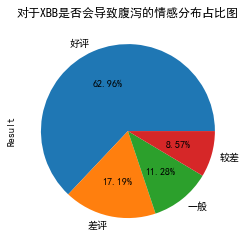

In [72]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
grp = data['Result'].value_counts()
print(grp)
grp.plot.pie(y='Result', autopct='%.2f%%')  # 画饼图
plt.title('对于XBB是否会导致腹泻的情感分布占比图')

In [74]:
data['score'].mean() #接近1，表明大部分的评论是积极的

0.7113237783284704

In [76]:
data.head()

,item_id,rater_uid,feedback,,gmt_create,score,Result
0,3,u10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,NaN,2013-06-27 16:50:13,0.998604,好评
1,4,u7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,NaN,2013-08-22 17:15:45,0.991384,好评
2,4,u6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,NaN,2013-08-18 11:07:29,0.990086,好评
3,5,u7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,NaN,2013-08-29 15:26:50,0.300676,较差
4,5,u530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,NaN,2013-07-24 19:24:22,0.987733,好评


### 1.1.4 保存

In [77]:
#获得有情感分的评论数据
data.to_csv('D:\\Datas\\datas\\r_review.csv', index=False)

(-0.5, 3099.5, 3099.5, -0.5)

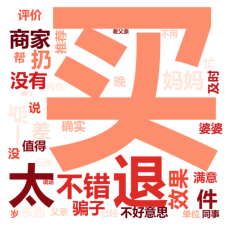

In [19]:
# 导入所需库
from wordcloud import WordCloud, ImageColorGenerator
import matplotlib.pyplot as plt
import jieba
from imageio import imread

# 提供的评论数据
data = [('买 了 一 件 不 能 用 ， 妈妈 让 退 ， 商家 不 给 退 ， 扔 了 。 一点 效果 也 没有 。 太 差 。 骗子 ',),
        ('不好意思 ， 评价 晚 了 ， 太 忙 了 ， 东西 确实 很 不错 ， 值得 推荐 给 大家 啊 。 ',),
        ('婆婆 用 上 了 ， 很 满意 ！ ',),
        ('很 好 ， 没 说 的 。 很 及时 。 ',),
        ('帮 单位 同事 父亲 买 的 ， 已经 有 80 多 岁 了 ， 反映 还 不错 ， 他 再也 不用 和 老父亲 大 着 嗓门 说话 了 ',)]

# 分词处理
def cut_word(text):
    return jieba.lcut(text)

list2 = [cut_word(text[0]) for text in data]

# 加载停用词
stopwords = set()
with open('中文停用词表.txt', 'r', encoding='UTF-8') as f:
    for line in f:
        stopwords.add(line.strip())

# 停用词处理
def remove_stopword(words):
    return [word for word in words if word not in stopwords]

list3 = [remove_stopword(words) for words in list2]

# 合并分词结果
words = []
for words_list in list3:
    words.extend(words_list)

words=' '.join(words)

# 生成词云图
bg_pic = imread('人物.png')


#设置词云字体
font_wc= r'C:\Windows\Fonts\msyhbd.ttc'

#生成词云
wc = WordCloud(font_path=font_wc
               ,mask=bg_pic
               ,max_words=500
               ,max_font_size=200
               ,background_color='white'
               ,colormap= 'Reds_r'
               ,scale=15.5)

#生成词云 
wc.generate(words)
plt.imshow(wc)
plt.axis('off')

### 1.1.5 词云图设计

In [3]:
#分词
import jieba
#返回生成器
def cut_word(text):
    return jieba.cut(text,cut_all=False)

    
data['feedback_cut'] = data['feedback'].apply(cut_word)
#停用词处理
def get_stopword():
    s = set()
    with open('哈工大停用词表.txt',encoding = 'UTF-8') as f:
        for line in f:
            s.add(line.strip())
    return s




def remove_stopword(words):
    return [word for word in words if word not in stopword]

stopword = get_stopword()
data['feedback_cut'] = data['feedback_cut'].apply(remove_stopword)
data.head()

Building prefix dict from the default dictionary ...
Loading model from cache C:\Users\LFF\AppData\Local\Temp\jieba.cache
Loading model cost 0.611 seconds.
Prefix dict has been built successfully.


,item_id,rater_uid,feedback,,gmt_create,feedback_cut
0,3,u10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,NaN,2013-06-27 16:50:13,"[ , 妈妈, , 买, , , 妈妈, , 很, , 喜欢, , , , ..."
1,4,u7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,NaN,2013-08-22 17:15:45,"[物流, , 很, , 给力, , , 老板, , 服务, , 态度, , ..."
2,4,u6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,NaN,2013-08-18 11:07:29,"[很, , 好, , , 安装, , 方便, , , 非常, , 实惠, ,..."
3,5,u7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,NaN,2013-08-29 15:26:50,"[包装, , 严实, , , 买, , , 6, , 瓶, , , 一点, ..."
4,5,u530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,NaN,2013-07-24 19:24:22,"[打包, , , 都, , 挺, 好, , , 挺, , 细心, , , ..."


In [36]:
from wordcloud import WordCloud
from imageio import imread
bg_pic = imread('heart.png')

#设置词云字体
font_wc= r'C:\Windows\Fonts\msyhbd.ttc'

#生成词云
wc = WordCloud(font_path=font_wc
               ,mask=bg_pic
               ,max_words=500
               ,max_font_size=200
               ,background_color='white'
               ,colormap= 'Reds_r'
               ,scale=15.5)

(-0.5, 15871.5, 15871.5, -0.5)

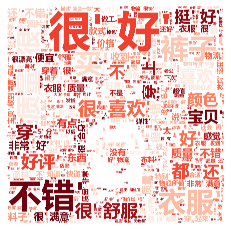

In [39]:
#生成词云 
myText=' '.join(df_words['review'].astype(str))

wc.generate(myText)
plt.imshow(wc)
plt.axis('off')

## 1.2 规范数据 <a class="anchor" id="section1_2"></a>

### 1.2.1 读取情感分析保存的数据

In [19]:
#读取有打分的数据
import pandas as pd

chunk_size = 500000 # 每一块的行数
chunks = []

for chunk in pd.read_csv('D:\\Datas\\datas\\r_review.csv', chunksize=chunk_size):
    # 处理每个chunk的数据
    chunks.append(chunk)
data_1 = pd.concat(chunks, axis=0)
data_1.head(10)

,item_id,rater_uid,feedback,,gmt_create,score,Result
0,3,u10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,NaN,2013-06-27 16:50:13,0.998604,好评
1,4,u7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,NaN,2013-08-22 17:15:45,0.991384,好评
2,4,u6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,NaN,2013-08-18 11:07:29,0.990086,好评
3,5,u7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,NaN,2013-08-29 15:26:50,0.300676,较差
4,5,u530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,NaN,2013-07-24 19:24:22,0.987733,好评
5,5,u9902915,商品 没 的 说 ， 很 好 ， 包装 很 结实 ， 打开 箱子 笑 的 我 来 ， 包裹 ...,NaN,2013-09-05 16:34:28,0.000014,差评
6,5,u9621739,就是 这 个 味 ， 满意 ！ 还 可以 哦,NaN,2013-09-29 20:04:25,0.461210,较差
7,6,u11614546,买 了 一 件 不 能 用 ， 妈妈 让 退 ， 商家 不 给 退 ， 扔 了 。 一点 效...,NaN,2013-09-15 13:09:27,0.000024,差评
8,6,u13715238,不好意思 ， 评价 晚 了 ， 太 忙 了 ， 东西 确实 很 不错 ， 值得 推荐 给 大...,NaN,2013-05-23 10:55:42,0.859307,好评
9,6,u462198,婆婆 用 上 了 ， 很 满意 ！,NaN,2013-06-03 14:09:32,0.897315,好评


### 1.2.2 找出评论最多的数据

In [20]:
#为了能更好的展示分析效果选中评论最多的来显示
# 计算item_id出现次数
item_id_counts = data_1['item_id'].value_counts()

# 找到出现次数最多的item_id
max_count_item_id = item_id_counts.idxmax()

# 筛选出出现次数最多的item_id对应的商品信息
most_frequent_item_info = data_1[data_1['item_id'] == max_count_item_id]

print("出现次数最多的item_id：", max_count_item_id)
print("对应的商品信息：")
print(most_frequent_item_info)

出现次数最多的item_id： 75881
对应的商品信息：
        item_id  rater_uid                                           feedback  \
103752    75881   u4598464  拿 到 了 之后 就 马上 去 洗 了   没 掉色   很 不错   物流 很 给力   ...   
103753    75881   u4857538  东 东 收到 ， 确实 是 正品 ， 质量 很 好 ， 手感 不错 ， 花色 也 很 漂亮 ...   
103754    75881   u1081720  质量 看 起来 还 不错 ， 款式 也 喜欢 ， 卖家 发货 很 速度 。 赞 一个 啊 ！ ！    
103755    75881  u12817992         是 正品 ， 质量 很 好 ， 盖 着 很 舒服 ， 图案 也 很 漂亮 ， 喜欢    
103756    75881   u1292253                 质量 好 。 手感 舒服 ， 面料 给力 ， 不 缩水 ， 赞 。    
103757    75881   u2697461                             宝贝 不错 ， 质量 很 好 我 很 满意    
103758    75881  u10977075  质量 非常 好 ， 与 卖家 描述 的 完全 一致 ， 非常 满意   卖家 的 服务 太 ...   
103759    75881   u7810285                颜色 很 正 ， 非常 漂亮 的 花色 ， 摸 起来 质感 也 不错    
103760    75881   u8171151  宝贝 很 不错   摸 着 很 舒服   洗 了 下 也 不 褪色   很 不错 的 宝贝 ...   
103761    75881   u9974828                   还是 挺 不错 的 ， 质量 还 可以 ， 卖家 服务 很 好    
103762    75881   u3466087  质量 非常 好 ， 手感 不错 ， 摸 着 很 舒服 ， 款式 也 喜欢 ， 花色 也 很 ... 

### 1.2.3 可视化评论量最多的商品

好评    14
一般     1
Name: Result, dtype: int64


Text(0.5, 1.0, '对于XBB是否会导致腹泻的情感分布占比图')

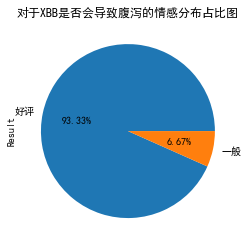

In [5]:
import matplotlib.pyplot as plt

plt.rcParams['font.sans-serif'] = ['SimHei'] 
grp = most_frequent_item_info['Result'].value_counts()
print(grp)
grp.plot.pie(y='Result', autopct='%.2f%%')  # 画饼图
plt.title('对于XBB是否会导致腹泻的情感分布占比图')

In [21]:
data_1.head()

,item_id,rater_uid,feedback,,gmt_create,score,Result
0,3,u10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,NaN,2013-06-27 16:50:13,0.998604,好评
1,4,u7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,NaN,2013-08-22 17:15:45,0.991384,好评
2,4,u6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,NaN,2013-08-18 11:07:29,0.990086,好评
3,5,u7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,NaN,2013-08-29 15:26:50,0.300676,较差
4,5,u530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,NaN,2013-07-24 19:24:22,0.987733,好评


### 1.2.4 对情感分分类

In [23]:
import pandas as pd

# 定义分类区间（按小数点后三位进行分段）
bins = [0, 0.199, 0.399, 0.599, 0.799, 1]
labels = ['1', '2', '3', '4', '5']

# 对Result字段进行分类
data_1['score_class'] = pd.cut(data_1['score'], bins=bins, labels=labels, include_lowest=True)

# 显示结果
data_1.head()

,item_id,rater_uid,feedback,,gmt_create,score,Result,score_class
0,3,u10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,NaN,2013-06-27 16:50:13,0.998604,好评,5
1,4,u7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,NaN,2013-08-22 17:15:45,0.991384,好评,5
2,4,u6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,NaN,2013-08-18 11:07:29,0.990086,好评,5
3,5,u7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,NaN,2013-08-29 15:26:50,0.300676,较差,2
4,5,u530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,NaN,2013-07-24 19:24:22,0.987733,好评,5


### 1.2.5 删除空白列

In [24]:
# 删除包含空白值的列
data_1 = data_1.dropna(axis=1, how='all')
# 显示处理后的DataFrame
data_1.head()

,item_id,rater_uid,feedback,gmt_create,score,Result,score_class
0,3,u10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,2013-06-27 16:50:13,0.998604,好评,5
1,4,u7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,2013-08-22 17:15:45,0.991384,好评,5
2,4,u6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,2013-08-18 11:07:29,0.990086,好评,5
3,5,u7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,2013-08-29 15:26:50,0.300676,较差,2
4,5,u530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,2013-07-24 19:24:22,0.987733,好评,5


### 1.2.6 规范用户id

In [26]:
#使得页面统计和处理更方便
# 删除rater_uid字段中的'u'
data_1['rater_uid'] = data_1['rater_uid'].str.replace('u', '')

# 显示处理后的DataFrame
data_1.head()

,item_id,rater_uid,feedback,gmt_create,score,Result,score_class
0,3,10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,2013-06-27 16:50:13,0.998604,好评,5
1,4,7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,2013-08-22 17:15:45,0.991384,好评,5
2,4,6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,2013-08-18 11:07:29,0.990086,好评,5
3,5,7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,2013-08-29 15:26:50,0.300676,较差,2
4,5,530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,2013-07-24 19:24:22,0.987733,好评,5


### 1.2.7 规范时间戳

In [29]:
import pandas as pd

# 将gmt_create字段转换为日期时间类型，并提取年月日部分
data_1['gmt_create'] = pd.to_datetime(data_1['gmt_create']).dt.strftime('%Y-%m-%d')

# 显示处理后的DataFrame
data_1.head()

,item_id,rater_uid,feedback,gmt_create,score,Result,score_class
0,3,10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,2013-06-27,0.998604,好评,5
1,4,7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,2013-08-22,0.991384,好评,5
2,4,6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,2013-08-18,0.990086,好评,5
3,5,7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,2013-08-29,0.300676,较差,2
4,5,530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,2013-07-24,0.987733,好评,5


### 1.2.8 保存数据

In [30]:
#保存方便后续做筛选的数据
data_1.to_csv('D:\\Datas\\datas\\r_review_1.csv', index=False)

# 2.  关于对商品数据的分析  <a class="anchor" id="section2"></a>

## 2.1 合并表   <a class="anchor" id="section2_1"></a>

>将两个MySQL数据库中的表通过item_id字段进行连接，并创建一个新的表，以显示两个表的字段，具体实现方法建立一个新表，对新表插入两个表所需字段以item_id进行连接

### 2.1.1 创建新表

```SQL
CREATE TABLE `product` (
  `ID` int NOT NULL AUTO_INCREMENT,
  `item_id` int NOT NULL,
  `title` text CHARACTER SET utf8mb4 COLLATE utf8mb4_general_ci,
  `pict_url` varchar(255) CHARACTER SET utf8mb4 COLLATE utf8mb4_general_ci DEFAULT NULL,
  `alipay` int DEFAULT NULL,
  `cart` int DEFAULT NULL,
  `click` int DEFAULT NULL,
  `collect` int DEFAULT NULL,
  PRIMARY KEY (`ID`,`item_id`),
  KEY `item_id` (`item_id`),
  KEY `ID` (`ID`,`item_id`),
  CONSTRAINT `product_ibfk_1` FOREIGN KEY (`item_id`) REFERENCES `item_action_count` (`item_id`)
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_general_ci;
```

### 2.1.2 连接查询

>使用连接查询（JOIN）将两个表连接起来，根据它们的item_id字段进行匹配。

示例如下:
```SQL
SELECT table1.item_id, table1.field1, table2.field2, table2.field3
FROM table1
JOIN table2 ON table1.item_id = table2.item_id;
```

实现
```SQL
INSERT INTO product (item_id, field1, field2, field3)
SELECT product_sample.item_id, product_sample.title, product_sample.pict_url, item_action_count.alipay, item_action_count.cart, item_action_count.click, item_action_count.collect
FROM product_sample
JOIN item_action_count ON product_sample.item_id = item_action_count.item_id;
```

In [ ]:
#!pip install pymysql

In [17]:
import pymysql
import pandas as pd

# 连接数据库
connection = pymysql.connect(
    host='localhost',
    user='root',
    password='296692',
    database='e-commerce_platform',
    charset='utf8mb4',
    cursorclass=pymysql.cursors.DictCursor
)

try:
    # 创建游标对象
    with connection.cursor() as cursor:
        # 执行查询语句
        sql = "SELECT * FROM product limit 10"
        cursor.execute(sql)

        # 获取查询结果
        result = cursor.fetchall()

        # 将查询结果转换为DataFrame
        df = pd.DataFrame(result)

        # 展示DataFrame
        print(df)

finally:
    # 关闭数据库连接
    connection.close()

        ID  item_id                                              title  \
0  8261107        1  韩 惑   2013 秋装 新款   韩国进口 女装   圆领 下摆 条纹 蓬松 连衣裙  ...   
1  8261108        2      车 品 世家   进口 大众 EOS 专用后备箱垫 汽车尾箱垫 皮革 行李箱垫 超 耐磨    
2  8261109        3    2013 秋冬季 新款 女士 黑色短裙 半身裙   烫钻 加 长裙 大码 裙 胖 mm 裙子    
3  8261110        4      花 画饰 界 高档 现代 简约 摄影 马 客厅 玄关 中 欧式 电表箱 有框装饰画 新品    
4  8261111        5  吉 香 居 【 210 风味豆豉 】 拌饭   拌面酱   调味品   豉 香 浓郁   四...   
5  8261112        6   西门子   老人 耳背式   助听器   莲花 心动 型 无线 老年人 助听 机   正品包邮    
6  8261113        7                   你 不 可 不知 的 宇宙 探索 百科   学生 探索 书 系    
7  8261114        8  2012年 新品   正品 彪马 / PUMA   Fundamentals   双肩背包 ...   
8  8261115        9             伊诗比蒂 丛林 小象 超柔 音乐 爬行垫   婴幼儿 游戏垫   正品包邮    
9  8261116       10  双 季 树莓   连续 结果 的 树莓 新 品种   帝 果 红树莓 俗称 四季 红树莓 树...   

                                            pict_url  alipay  cart  click  \
0  http://img01.taobaocdn.com/bao/uploaded/i3/132...       1     9    389   
1  http://img01.taobaocdn.com/b

# 3.  关于对用户行为数据的分析  <a class="anchor" id="section3"></a>

## 3.1 规范化数据  <a class="anchor" id="section3_1"></a>

### 3.1.1 读取用户行为数据

In [31]:
import pandas as pd


chunk_size = 500000 # 每一块的行数
chunks = []

for chunk in pd.read_csv('D:\\Datas\\datas\\action.csv', chunksize=chunk_size):
    # 处理每个chunk的数据
    chunks.append(chunk)
action = pd.concat(chunks, axis=0)
action.head(10)

,item_id,user_id,action,vtime
0,1,u1144920,click,2013-09-18 22:34:26
1,1,u13739929,click,2013-09-26 23:30:28
2,1,u9989957,click,2013-09-26 23:27:55
3,1,u4722735,click,2013-09-14 21:21:27
4,1,u5379171,click,2013-09-18 00:16:23
5,1,u10541267,click,2013-09-30 19:29:31
6,1,u2224274,click,2013-09-30 15:09:51
7,1,u11564774,click,2013-09-17 21:06:05
8,1,u2224274,click,2013-09-30 14:24:11
9,1,u5372775,click,2013-09-07 09:09:11


### 3.1.2 规范user_id 

>在处理大量数据时，直接对DataFrame进行操作可能会导致内存问题，尤其是在对字符串列进行大规模替换操作时。这是因为DataFrame会将整个数据集加载到内存中，如果数据量很大，对整个数据集进行处理可能会导致内存耗尽。为了避免内存问题，可以考虑采用逐块读取数据并批量处理的方式来减少内存压力。

In [2]:
#方便页面统计和处理
#分批处理
import pandas as pd

# action为大量数据的DataFrame
chunk_size = 100000  # 块大小
chunks = []

# 逐块处理数据
for chunk in pd.read_csv('D:\\Datas\\datas\\action.csv', chunksize=chunk_size):
    chunk['user_id'] = chunk['user_id'].astype(str).str.replace('u', '')
    chunks.append(chunk)
action = pd.concat(chunks, axis=0)
action.head(10)

,item_id,user_id,action,vtime
0,1,1144920,click,2013-09-18 22:34:26
1,1,13739929,click,2013-09-26 23:30:28
2,1,9989957,click,2013-09-26 23:27:55
3,1,4722735,click,2013-09-14 21:21:27
4,1,5379171,click,2013-09-18 00:16:23
5,1,10541267,click,2013-09-30 19:29:31
6,1,2224274,click,2013-09-30 15:09:51
7,1,11564774,click,2013-09-17 21:06:05
8,1,2224274,click,2013-09-30 14:24:11
9,1,5372775,click,2013-09-07 09:09:11


In [3]:
#保存方便后续规范
action.to_csv('D:\\Datas\\datas\\action_1.csv', index=False)

### 3.1.3 规范时间戳

In [1]:
#方便页面统计和处理
#分批处理
import pandas as pd

# action为大量数据的DataFrame
chunk_size = 100000  # 块大小
chunks = []

# 逐块处理数据
for chunk in pd.read_csv('D:\\Datas\\datas\\action_1.csv', chunksize=chunk_size):
    # 将vtime字段转换为日期时间类型，并提取年月日部分
    chunk['vtime'] = pd.to_datetime(chunk['vtime']).dt.strftime('%Y-%m-%d')
    chunks.append(chunk)
action = pd.concat(chunks, axis=0)
action.head(10)

,item_id,user_id,action,vtime
0,1,1144920,click,2013-09-18
1,1,13739929,click,2013-09-26
2,1,9989957,click,2013-09-26
3,1,4722735,click,2013-09-14
4,1,5379171,click,2013-09-18
5,1,10541267,click,2013-09-30
6,1,2224274,click,2013-09-30
7,1,11564774,click,2013-09-17
8,1,2224274,click,2013-09-30
9,1,5372775,click,2013-09-07


In [2]:
#保存方便后续规范
action.to_csv('D:\\Datas\\datas\\action_2.csv', index=False)

## 3.2 统计用户行为  <a class="anchor" id="section3_2"></a>

### 3.2.1 统计购买量、点击量、收藏量、加入购物车量

In [4]:
import pandas as pd

# action为大量数据的DataFrame
chunk_size = 100000  # 块大小
chunks = []

# 逐块处理数据
for chunk in pd.read_csv('D:\\Datas\\datas\\action_2.csv', chunksize=chunk_size):
    # 将vtime字段转换为日期时间类型，并提取年月日部分
    chunks.append(chunk)
action = pd.concat(chunks, axis=0)
action.head(10)

,item_id,user_id,action,vtime
0,1,1144920,click,2013-09-18
1,1,13739929,click,2013-09-26
2,1,9989957,click,2013-09-26
3,1,4722735,click,2013-09-14
4,1,5379171,click,2013-09-18
5,1,10541267,click,2013-09-30
6,1,2224274,click,2013-09-30
7,1,11564774,click,2013-09-17
8,1,2224274,click,2013-09-30
9,1,5372775,click,2013-09-07


In [9]:
df = pd.DataFrame(action)

# 使用groupby和agg进行分组并统计数量
result = df.groupby(['item_id', 'action']).agg(count=('user_id', 'count')).reset_index()
result.head()

,item_id,action,count
0,1,alipay,1
1,1,cart,9
2,1,click,389
3,1,collect,11
4,2,click,1


### 3.2.2 拆分action列

In [15]:
#方便查找
import pandas as pd

df = pd.DataFrame(result)

# 使用pivot函数将action字段拆分为四个字段
df_pivot = df.pivot(index='item_id', columns='action', values='count').reset_index()
df_pivot = df_pivot.rename_axis(None, axis=1)

# 填充缺失值（NaN）并重命名列名
df_pivot = df_pivot.fillna(0)
df_pivot = df_pivot.astype({'alipay': int, 'cart': int, 'click': int, 'collect': int})
df_pivot.head()

,item_id,alipay,cart,click,collect
0,1,1,9,389,11
1,2,0,0,1,0
2,3,0,16,364,7
3,4,0,0,12,0
4,5,2,11,75,3


### 3.2.2 保存

In [16]:
#保存方便渲染页面
df_pivot.to_csv('D:\\Datas\\datas\\action_count.csv', index=False)

## 3.3 优质客户  <a class="anchor" id="section3_3"></a>

### 3.3.1 统计用户购买、添加 如上操作

In [1]:
import pandas as pd

# action为大量数据的DataFrame
chunk_size = 100000  # 块大小
chunks = []

# 逐块处理数据
for chunk in pd.read_csv('D:\\Datas\\datas\\action_2.csv', chunksize=chunk_size):
    chunks.append(chunk)
action = pd.concat(chunks, axis=0)
action.head(10)

,item_id,user_id,action,vtime
0,1,1144920,click,2013-09-18
1,1,13739929,click,2013-09-26
2,1,9989957,click,2013-09-26
3,1,4722735,click,2013-09-14
4,1,5379171,click,2013-09-18
5,1,10541267,click,2013-09-30
6,1,2224274,click,2013-09-30
7,1,11564774,click,2013-09-17
8,1,2224274,click,2013-09-30
9,1,5372775,click,2013-09-07


In [2]:
df = pd.DataFrame(action)

# 按照用户id分组并统计action数量
# 使用groupby和agg进行分组统计
result = df.groupby(['user_id', 'action']).size().unstack(fill_value=0).reset_index()
result.head()

action,user_id,alipay,cart,click,collect
0,1,0,0,2,0
1,3,0,0,3,0
2,4,0,2,19,1
3,5,0,0,8,1
4,7,0,1,26,0


In [11]:
# 按照alipay字段从大到小排序
df_alipay = result.sort_values(by='alipay', ascending=False)

# 按照cart字段从大到小排序
df_cart = result.sort_values(by='cart', ascending=False)

# 按照click字段从大到小排序
df_click = result.sort_values(by='click', ascending=False)

# 按照collect字段从大到小排序
df_collect = result.sort_values(by='collect', ascending=False)

In [12]:
df_alipay.head()

action,user_id,alipay,cart,click,collect
1619280,2669833,817,82,1321,0
4620275,7618108,262,102,586,0
7053993,11630276,188,133,395,0
2573125,4241681,186,143,271,0
888585,1465072,176,4,333,0


In [13]:
# 删除cart、click、collect列
df_alipay = df_alipay.drop(columns=['cart', 'click', 'collect'])
df_alipay.head()

action,user_id,alipay
1619280,2669833,817
4620275,7618108,262
7053993,11630276,188
2573125,4241681,186
888585,1465072,176


In [14]:
#保存方便渲染页面   购买统计
df_alipay.to_csv('D:\\Datas\\datas\\user_alipay.csv', index=False)

In [15]:
# 按照cart字段从大到小排序
df_cart = result.sort_values(by='cart', ascending=False)
# 删除alipay、click、collect列
df_cart = df_cart.drop(columns=['alipay', 'click', 'collect'])
df_cart.head()

action,user_id,cart
6773987,11168431,440
2157599,3556436,271
4486253,7396485,210
5593838,9223025,186
4737458,7810419,186


In [16]:
#保存方便渲染页面  添加购物车统计
df_cart.to_csv('D:\\Datas\\datas\\user_cart.csv', index=False)

## 3.4 合并表   <a class="anchor" id="section3_4"></a>

### 3.4.1 新建表

```SQL
CREATE TABLE `user_action` (
  `ID` int NOT NULL AUTO_INCREMENT,
  `user_id` int DEFAULT NULL,
  `alipay` int DEFAULT NULL,
  `cart` int DEFAULT NULL,
  PRIMARY KEY (`ID`),
  KEY `alipay` (`user_id`) USING BTREE
) ENGINE=InnoDB DEFAULT CHARSET=utf8mb4 COLLATE=utf8mb4_general_ci;
```

### 3.4.2 执行连接查询

```SQL
SELECT user_alipay.user_id, user_alipay.alipay, user_cart.cart
FROM user_alipay
JOIN user_cart ON user_alipay.user_id = user_cart.user_id;
```

### 3.4.3 结果插入新表

```SQL
INSERT INTO user_action (user_id, alipay, cart)
SELECT user_alipay.user_id, user_alipay.alipay, user_cart.cart
FROM user_alipay
JOIN user_cart ON user_alipay.user_id = user_cart.user_id;
```

### 3.4.4 结果展示

In [18]:
import pymysql
import pandas as pd

# 连接数据库
connection = pymysql.connect(
    host='localhost',
    user='root',
    password='296692',
    database='e-commerce_platform',
    charset='utf8mb4',
    cursorclass=pymysql.cursors.DictCursor
)

try:
    # 创建游标对象
    with connection.cursor() as cursor:
        # 执行查询语句
        sql = "SELECT * FROM user_action limit 10"
        cursor.execute(sql)

        # 获取查询结果
        result = cursor.fetchall()

        # 将查询结果转换为DataFrame
        df = pd.DataFrame(result)

        # 展示DataFrame
        print(df)

finally:
    # 关闭数据库连接
    connection.close()

   ID   user_id  alipay  cart
0   1  11168431       3   440
1   2   3556436      48   271
2   3   7396485       3   210
3   4   9223025       2   186
4   5   7810419     167   186
5   6  14749415      61   185
6   7   4727025       0   175
7   8   2081262     148   174
8   9   1786968      53   166
9  10   6665272       0   159


# 4. 推荐系统  <a class="anchor" id="section4"></a>

## 4.1 基于ALS（交替最小二乘法）的协同过滤推荐  <a class="anchor" id="section4_1"></a>

>使用Spark来实现基于ALS（交替最小二乘法）的协同过滤推荐用于在用户-物品评分数据上进行推荐。

ALS(maxIter=5, regParam=0.01, userCol="rater_uid", itemCol="item_id", ratingCol="score_class",
          coldStartStrategy="drop")
- 参数说明如下：
* maxIter：迭代次数，指定算法运行的最大迭代次数。
* regParam：正则化参数，用于控制模型的正则化程度。较大的值可以减少过拟合的风险。
* userCol：指定包含用户ID的列名。
* itemCol：指定包含物品ID的列名。
* ratingCol：指定包含评分的列名。
* coldStartStrategy：冷启动策略，用于处理在训练期间遇到的新用户或新物品。"drop"表示在训练过程中删除具有冷启动的行。

### 4.1.1 导入PySpark

>在 Jupyter Notebook 中启动 PySpark 运行环境。使用 findspark 库来帮助将 PySpark 添加到 Python 路径中

In [1]:
import findspark
findspark.init()

### 4.1.2 导入必要的模块和创建 Spark 会话

In [2]:
from pyspark.sql import SparkSession
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.sql import Row

# 创建 Spark 会话
spark = SparkSession.builder.appName("RecommendationSystem").getOrCreate()


In [3]:
import pandas as pd

# action为大量数据的DataFrame
chunk_size = 100000  # 块大小
chunks = []

# 逐块处理数据
for chunk in pd.read_csv('D:\\Datas\\datas\\r_review_1.csv', chunksize=chunk_size):
    chunks.append(chunk)
review = pd.concat(chunks, axis=0)
review.head(10)

,item_id,rater_uid,feedback,gmt_create,score,Result,score_class
0,3,10362825,给 妈妈 买 地 妈妈 很 喜欢 发货 很快,2013-06-27,0.998604,好评,5
1,4,7408750,物流 很 给力 ， 老板 服务 态度 也 很 热情 哦 ， 画 也 很 漂亮 ， 下次 还 ...,2013-08-22,0.991384,好评,5
2,4,6374363,很 好 ， 安装 方便 ， 非常 实惠 ， 店主 人 也 很 好 ， 还 会 介绍 朋友 光...,2013-08-18,0.990086,好评,5
3,5,7523304,包装 严实 ， 买 了 6 瓶 ， 一点 没有 问题 。,2013-08-29,0.300676,较差,2
4,5,530539,打包 的 都 挺好 ， 挺 细心 ， 和 以前 吃 的 一个 味道,2013-07-24,0.987733,好评,5
5,5,9902915,商品 没 的 说 ， 很 好 ， 包装 很 结实 ， 打开 箱子 笑 的 我 来 ， 包裹 ...,2013-09-05,0.000014,差评,1
6,5,9621739,就是 这 个 味 ， 满意 ！ 还 可以 哦,2013-09-29,0.461210,较差,3
7,6,11614546,买 了 一 件 不 能 用 ， 妈妈 让 退 ， 商家 不 给 退 ， 扔 了 。 一点 效...,2013-09-15,0.000024,差评,1
8,6,13715238,不好意思 ， 评价 晚 了 ， 太 忙 了 ， 东西 确实 很 不错 ， 值得 推荐 给 大...,2013-05-23,0.859307,好评,5
9,6,462198,婆婆 用 上 了 ， 很 满意 ！,2013-06-03,0.897315,好评,5


In [4]:
ratings = spark.createDataFrame(review[["item_id", "rater_uid", "score_class"]])
ratings.show()

+-------+---------+-----------+
|item_id|rater_uid|score_class|
+-------+---------+-----------+
|      3| 10362825|          5|
|      4|  7408750|          5|
|      4|  6374363|          5|
|      5|  7523304|          2|
|      5|   530539|          5|
|      5|  9902915|          1|
|      5|  9621739|          3|
|      6| 11614546|          1|
|      6| 13715238|          5|
|      6|   462198|          5|
|      6| 13508808|          4|
|      6| 11516955|          5|
|      8|  8556474|          5|
|      8|  6719969|          3|
|     10|   874546|          2|
|     11|  9425091|          1|
|     11|  3391480|          5|
|     12|  3710714|          5|
|     13| 10118236|          1|
|     14| 10226850|          4|
+-------+---------+-----------+
only showing top 20 rows



### 4.1.3 构建模型并加载数据

In [5]:
als = ALS(maxIter=5, regParam=0.01, userCol="rater_uid", itemCol="item_id", ratingCol="score_class",
          coldStartStrategy="drop")
model = als.fit(ratings)

### 4.1.4 生成推荐结果并展示

In [6]:
userRecs = model.recommendForAllUsers(5)  # 推荐每个用户前5个物品
userRecs.show()

+---------+--------------------+
|rater_uid|     recommendations|
+---------+--------------------+
|     2866|[[31502, 10.98880...|
|     7833|[[96504, 11.09504...|
|     9900|[[41034, 6.425269...|
|    23015|[[83918, 2.011738...|
|    32396|[[19557, 7.529346...|
|    76110|[[99098, 4.592021...|
|   200687|[[76996, 10.10176...|
|   207103|[[34677, 4.999544...|
|   235476|[[95444, 10.02363...|
|   239049|[[26581, 4.127050...|
|   280218|[[74846, 7.51366]...|
|   287992|[[94347, 10.66236...|
|   327299|[[94713, 9.68423]...|
|   331224|[[56763, 10.56337...|
|   341531|[[32645, 8.710129...|
|   346396|[[43540, 10.52614...|
|   368248|[[5490, 1.1682041...|
|   377793|[[1869, 10.552076...|
|   387142|[[88729, 4.256885...|
|   410299|[[31582, 6.457801...|
+---------+--------------------+
only showing top 20 rows



In [17]:
# 将DataFrame转换为Pandas DataFrame
pandas_df = userRecs.toPandas()

In [18]:
pandas_df.head()

,rater_uid,recommendations
0,2866,"[(31502, 10.988805770874023), (77160, 9.788437..."
1,7833,"[(96504, 11.095044136047363), (26004, 9.781147..."
2,9900,"[(41034, 6.42526912689209), (25497, 6.24135494..."
3,23015,"[(83918, 2.0117383003234863), (16580, 1.826595..."
4,32396,"[(19557, 7.529346466064453), (73208, 7.4593777..."


In [23]:
# 查看DataFrame的大小
print(pandas_df.shape)

(132879, 2)


In [26]:
#保存
pandas_df.to_csv('D:\\Datas\\datas\\recommendations.csv', index=False)

In [24]:
import pandas as pd
import pymysql

# 连接到MySQL数据库
connection = pymysql.connect(
    host='localhost',
    user='root',
    password='296692',
    db='e-commerce_platform'
)

# 将Pandas DataFrame保存到MySQL数据库中的表中
pandas_df.to_sql('recommendations', con=connection, if_exists='replace', index=False)

# 关闭数据库连接
connection.close()

DatabaseError: Execution failed on sql 'SELECT name FROM sqlite_master WHERE type='table' AND name=?;': not all arguments converted during string formatting

### 4.1.5 关闭Spark会话

In [48]:
spark.stop()

In [15]:
import pyspark
print(pyspark.__version__)

3.0.0


In [16]:
import py4j
print(py4j.__version__)

0.10.9


# 4.2 ALS模型评估   <a class="anchor" id="section4_2"></a>

### 4.2.1 加载数据

In [5]:
from pyspark.ml.evaluation import RegressionEvaluator
from pyspark.ml.recommendation import ALS
from pyspark.sql import SparkSession
import pandas as pd
from pyspark.sql.functions import col

# 创建Spark会话
spark = SparkSession.builder.getOrCreate()

# 加载评分数据集
# action为大量数据的DataFrame
chunk_size = 100000  # 块大小
chunks = []

# 逐块处理数据
for chunk in pd.read_csv('D:\\Datas\\datas\\r_review_1.csv', chunksize=chunk_size):
    chunks.append(chunk)
review = pd.concat(chunks, axis=0)
ratings = spark.createDataFrame(review[["item_id", "rater_uid", "score_class"]])
ratings.show()

+-------+---------+-----------+
|item_id|rater_uid|score_class|
+-------+---------+-----------+
|      3| 10362825|          5|
|      4|  7408750|          5|
|      4|  6374363|          5|
|      5|  7523304|          2|
|      5|   530539|          5|
|      5|  9902915|          1|
|      5|  9621739|          3|
|      6| 11614546|          1|
|      6| 13715238|          5|
|      6|   462198|          5|
|      6| 13508808|          4|
|      6| 11516955|          5|
|      8|  8556474|          5|
|      8|  6719969|          3|
|     10|   874546|          2|
|     11|  9425091|          1|
|     11|  3391480|          5|
|     12|  3710714|          5|
|     13| 10118236|          1|
|     14| 10226850|          4|
+-------+---------+-----------+
only showing top 20 rows



### 4.2.2 创建模型

In [21]:
# 数据集划分为训练集和测试集
(training, test) = ratings.randomSplit([0.8, 0.2])

# 创建ALS模型
als = ALS(maxIter=5, regParam=0.01, userCol="rater_uid", itemCol="item_id", ratingCol="score_class",
          coldStartStrategy="drop")

# 在训练集上拟合ALS模型
model = als.fit(training)

### 4.2.3 预测

In [22]:
# 在测试集上进行预测
predictions = model.transform(test)
predictions.show()

+-------+---------+-----------+----------+
|item_id|rater_uid|score_class|prediction|
+-------+---------+-----------+----------+
|  32592| 12903158|          5| 3.9972641|
|  66010|  5368089|          5|  4.997807|
|  71510|   421011|          4| 4.9978075|
|  82794| 14278992|          5|  4.997807|
|   2999|  4724633|          5|   4.99878|
|   9182|  6054978|          5| 4.9993277|
|  36706| 10296238|          1|  4.998699|
|  44321|  5923461|          5|  4.997807|
|  66562| 12536576|          5|  4.999501|
|  13009| 15349123|          4|  1.999065|
|  14289| 12585744|          5| 0.9998737|
|  14289|  9130599|          3|  2.999621|
|  17783|  3199545|          5| 0.2527395|
|  29630| 10960193|          5|  4.999438|
|  36591|    96892|          4|  4.998597|
|  50847| 15169290|          4|  4.997807|
|  62172|  4384344|          5| 3.9994864|
|   5074|  6269691|          5| 0.4496985|
|  10468|  4491723|          5| 3.9993112|
|  57398|  2756153|          1|  4.997807|
+-------+--

### 4.2.4 RMSE 与 MAE

> 均方根误差（RMSE）和平均绝对误差（MAE）：这两个评估指标用于衡量预测评分与实际评分之间的差异。RMSE和MAE的值越小，表示模型的预测准确性越高。

In [23]:
# 定义评估器（使用均方根误差和平均绝对误差）
evaluator_rmse = RegressionEvaluator(metricName="rmse", labelCol="score_class", predictionCol="prediction")
evaluator_mae = RegressionEvaluator(metricName="mae", labelCol="score_class", predictionCol="prediction")

# 计算均方根误差
rmse = evaluator_rmse.evaluate(predictions)
print("均方根误差 (RMSE) = {:.4f}".format(rmse))

# 计算平均绝对误差
mae = evaluator_mae.evaluate(predictions)
print("平均绝对误差 (MAE) = {:.4f}".format(mae))

均方根误差 (RMSE) = 2.6534
平均绝对误差 (MAE) = 1.6585


1. RMSE:衡量模型预测值与实际观测值之间差异的指标。RMSE的值越小，表示模型的预测准确性越高。RMSE为2.6534，这意味着模型的预测值平均上下浮动约2.6534个单位。
2. MAE:衡量模型预测值与实际观测值之间绝对差异的指标。MAE的值越小，表示模型的预测准确性越高。MAE为1.6585，这意味着模型的平均预测误差约为1.6585个单位。
3. RMSE为2.6534和MAE为1.6585，可以说模型的预测性能有一定的改进空间，因为较小的值表示模型的预测误差相对较小。

### 4.2.5 准确率和召回率

>准确率和召回率：这两个评估指标用于衡量推荐系统的精确性和覆盖率。准确率表示推荐列表中真正被用户喜欢的物品所占的比例，召回率表示真正被用户喜欢的物品在推荐列表中的比例。准确率和召回率的值都在0到1之间，越接近1表示推荐系统的性能越好。

In [16]:
from pyspark.sql.functions import col
from pyspark.sql.functions import collect_list, struct, explode
# 计算准确率和召回率
top_n = 5  # 推荐列表中的前n个物品
predictions_top_n = predictions.select("item_id", "rater_uid", "prediction") \
    .groupBy("rater_uid") \
    .agg(collect_list(struct("item_id", "prediction")).alias("recommendations"))

# 计算准确率和召回率
true_positive = predictions_top_n.join(test, ["rater_uid"]).selectExpr(
    "rater_uid", "item_id as true_item_id", "explode(recommendations.item_id) as recommended_item_id"
).where("recommended_item_id = true_item_id").count()

total_relevant = test.count()
total_recommended = predictions_top_n.select("rater_uid", explode("recommendations.item_id")).distinct().count()

precision = true_positive / total_recommended
recall = true_positive / total_relevant

print("准确率 = {:.4f}".format(precision))
print("召回率 = {:.4f}".format(recall))

准确率 = 1.0548
召回率 = 0.0392


### 4.2.6 关闭Spark会话

In [ ]:
# 关闭Spark会话
spark.stop()